In [0]:

_results = []
_stream = sqlutils.sql_stream("SELECT * FROM \"qbs_bronze\".\"sales_raw\" LIMIT 100", connection_id="6bzuya9ja69xcx")
for result in _stream:
    if result.status == "success":
        display(result.result)
        _results.append(result)
    else:
        # Save partial results for debugging before raising
        if len(_results) > 0:
            for r in _results:
                globals()[f'sql_output_c5y9_{r.statement_index}'] = r.result
        raise Exception(result.error)

# All statements succeeded - save indexed vars if multiple results
if len(_results) > 1:
    for r in _results:
        globals()[f'sql_output_c5y9_{r.statement_index}'] = r.result

# Always save main variable
sql_output_c5y9 = _results[0].result if len(_results) == 1 else [r.result for r in _results]


,order id,date,product,price,quantity,purchase type,payment method,manager,city
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin
...,...,...,...,...,...,...,...,...,...
95,10555,28-11-2022,Burgers,12.99,477.29,Online,Credit Card,Tom Jackson,London
96,10556,28-11-2022,Chicken Sandwiches,9.95,201.01,Online,Credit Card,Tom Jackson,London
97,10557,28-11-2022,Fries,3.49,630.37,Online,Credit Card,Tom Jackson,London
98,10558,28-11-2022,Beverages,2.95,677.97,Online,Credit Card,Tom Jackson,London


### Step 1 — Data Loading & Basic Inspection
Load `qbs_smus_bronze.sales_raw` into a pandas DataFrame and inspect shape, dtypes, sample rows, and missing values.

In [0]:
import pandas as pd

# Load table into pandas using the catalog reader (works natively in this environment)
df = pd.read_catalog_table(database="qbs_smus_bronze", table="sales_raw")

# Rename columns: strip spaces and lowercase for easier access
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Coerce numeric columns
df["price"]    = pd.to_numeric(df["price"],    errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

# Basic info
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn dtypes:\n{df.dtypes.to_string()}")
print(f"\nMissing values per column:\n{df.isnull().sum().to_string()}")
print(f"\nDuplicate rows: {df.duplicated().sum():,}")


Shape: 263 rows x 9 columns

Column dtypes:
order_id            int64
date               object
product            object
price             float64
quantity          float64
purchase_type      object
payment_method     object
manager            object
city               object

Missing values per column:
order_id          0
date              0
product           0
price             1
quantity          0
purchase_type     0
payment_method    0
manager           0
city              0

Duplicate rows: 1


In [0]:
# Sample rows and descriptive statistics
df.head(10)


,order_id,date,product,price,quantity,purchase_type,payment_method,manager,city
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin
5,10457,08-11-2022,Fries,3.49,573.07,In-store,Credit Card,Remy Monet,Paris
6,10459,08-11-2022,Sides & Other,4.99,200.40,In-store,Credit Card,Walter Muller,Berlin
7,10460,09-11-2022,Burgers,12.99,554.27,In-store,Credit Card,Remy Monet,Paris
8,10461,09-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Remy Monet,Paris
9,10462,09-11-2022,Fries,3.49,573.07,In-store,Credit Card,Remy Monet,Paris


In [0]:
df.describe()


,order_id,price,quantity
count,263.000000,262.000000,263.000000
mean,10262.737643,6.964351,451.370266
std,1714.503414,5.014046,222.639383
min,1023.000000,-30.500000,-21.000000
25%,10510.500000,3.490000,201.010000
50%,10579.000000,4.990000,538.880000
75%,10647.500000,9.950000,646.650000
max,10713.000000,29.050000,754.430000


In [0]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch

# ── Clean & prepare ──────────────────────────────────────────────────────────
_df = df.copy()
_df.columns = [c.strip().lower().replace(" ", "_") for c in _df.columns]
_df["manager"]  = _df["manager"].str.strip().str.replace(r"\s+", " ", regex=True)
_df["product"]  = _df["product"].str.strip()
_df["city"]     = _df["city"].str.strip()
_df["price"]    = pd.to_numeric(_df["price"],    errors="coerce")
_df["quantity"] = pd.to_numeric(_df["quantity"], errors="coerce")
_df = _df.drop_duplicates()
_df = _df[(_df["price"] >= 0) & (_df["quantity"] >= 0)].copy()
_df["date"]    = pd.to_datetime(_df["date"], dayfirst=True, errors="coerce")
_df = _df.dropna(subset=["date", "price", "quantity"])
_df["revenue"] = _df["price"] * _df["quantity"]
_df["week"]    = _df["date"].dt.to_period("W").apply(lambda p: p.start_time)

# ── Aggregations ─────────────────────────────────────────────────────────────
daily_rev = (
    _df.groupby("date")["revenue"].sum()
    .reset_index().rename(columns={"revenue": "daily_revenue"})
    .sort_values("date")
)
daily_rev["rolling_7d"] = daily_rev["daily_revenue"].rolling(7, min_periods=1).mean()

city_rev = (
    _df.groupby("city")
    .agg(total_revenue=("revenue", "sum"), total_orders=("order_id", "count"))
    .reset_index().sort_values("total_revenue", ascending=False)
)

prod_rev = (
    _df.groupby("product")
    .agg(total_revenue=("revenue", "sum"), total_qty=("quantity", "sum"), orders=("order_id", "count"))
    .reset_index().sort_values("total_revenue", ascending=False)
)

mgr_city = (
    _df.groupby(["city", "manager"])
    .agg(city_revenue=("revenue", "sum"))
    .reset_index()
    .sort_values("city_revenue", ascending=False)
    .drop_duplicates("city")
    .reset_index(drop=True)
)
mgr_city = mgr_city.merge(city_rev[["city", "total_orders"]], on="city", how="left")
mgr_city["city_revenue_fmt"] = mgr_city["city_revenue"].apply(lambda x: f"E{x:,.0f}")

top4 = prod_rev["product"].head(4).tolist()
weekly_prod = (
    _df[_df["product"].isin(top4)]
    .groupby(["week", "product"])["revenue"]
    .sum().reset_index()
)

ptype_rev = (
    _df.groupby("purchase_type")["revenue"].sum()
    .reset_index().sort_values("revenue", ascending=False)
)

pay_rev = (
    _df.groupby("payment_method")["revenue"].sum()
    .reset_index().sort_values("revenue", ascending=False)
)

heat = _df.pivot_table(index="product", columns="city", values="revenue", aggfunc="sum").fillna(0)

# ── Colour palette ────────────────────────────────────────────────────────────
BRAND  = "#1a1a2e"
ACC2   = "#0f3460"
GOLD   = "#e94560"
TEAL   = "#00b4d8"
LIME   = "#80ed99"
PURPLE = "#c77dff"
BG     = "#f7f9fc"
CITY_PALETTE = [TEAL, GOLD, LIME, PURPLE, "#ffd166", "#06d6a0", "#ef476f", "#118ab2"]

print(f"Clean records : {_df.shape[0]:,}")
print(f"Date range    : {_df['date'].min().date()} to {_df['date'].max().date()}")
print(f"Total revenue : E{_df['revenue'].sum():,.2f}")


Clean records : 257
Date range    : 2022-11-07 to 2023-12-25
Total revenue : E774,981.58


### Dashboard 1 — Revenue Over Time

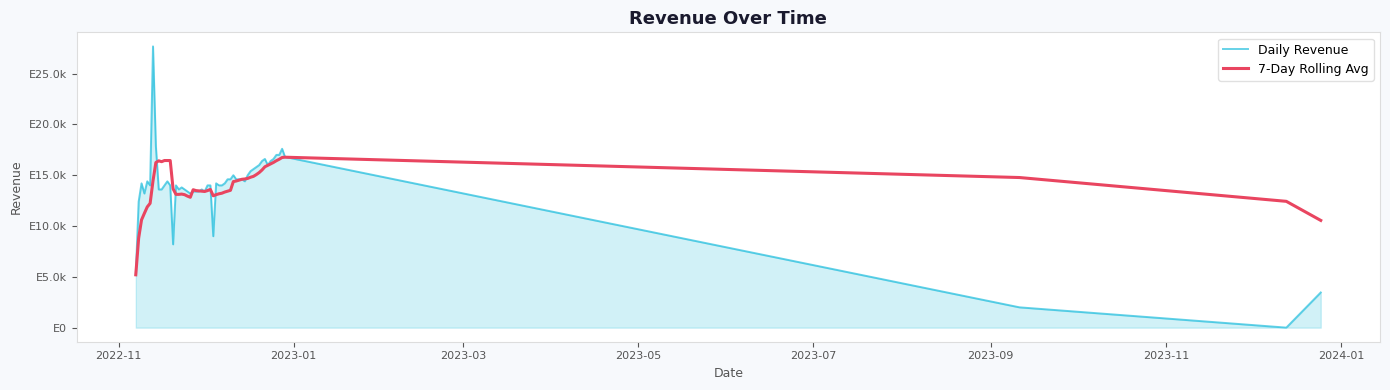

In [0]:
# Dashboard 1 — Revenue Over Time
fig1, ax = plt.subplots(figsize=(14, 4), facecolor=BG)
ax.set_facecolor("white")
ax.fill_between(daily_rev["date"], daily_rev["daily_revenue"], alpha=0.18, color=TEAL)
ax.plot(daily_rev["date"], daily_rev["daily_revenue"],
        color=TEAL, linewidth=1.4, alpha=0.6, label="Daily Revenue")
ax.plot(daily_rev["date"], daily_rev["rolling_7d"],
        color=GOLD, linewidth=2.2, label="7-Day Rolling Avg")
ax.set_title("Revenue Over Time", fontsize=13, fontweight="bold", color=BRAND)
ax.set_xlabel("Date", fontsize=9, color="#555")
ax.set_ylabel("Revenue", fontsize=9, color="#555")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"E{x/1000:.1f}k" if x >= 1000 else f"E{x:.0f}"
))
ax.tick_params(colors="#555", labelsize=8)
ax.legend(fontsize=9, framealpha=0.6)
for sp in ax.spines.values():
    sp.set_edgecolor("#ddd")
plt.tight_layout()
plt.show()


,date,daily_revenue,rolling_7d
0,2022-11-07,5200.0023,5200.002300
1,2022-11-08,12400.0731,8800.037700
2,2022-11-09,14200.0386,10600.038000
3,2022-11-10,13200.0426,11250.039150
4,2022-11-11,14400.0156,11880.034440
5,2022-11-12,14000.0535,12233.370950
6,2022-11-13,27674.4512,14439.239557
7,2022-11-14,17839.3445,16244.859871
8,2022-11-15,13600.0305,16416.282357
9,2022-11-16,13600.0305,16330.566914


# Dashboard 2 — Revenue by City & Product
fig2, (ax_city, ax_prod) = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

ax_city.set_facecolor("white")
bars = ax_city.bar(city_rev["city"], city_rev["total_revenue"],
                   color=CITY_PALETTE[:len(city_rev)], edgecolor="white", linewidth=0.8)
for bar in bars:
    ax_city.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + city_rev["total_revenue"].max() * 0.01,
                 f"E{bar.get_height():,.0f}", ha="center", va="bottom", fontsize=8, color=BRAND)
ax_city.set_title("Revenue by City / Branch", fontsize=12, fontweight="bold", color=BRAND)
ax_city.set_xlabel("City", fontsize=9, color="#555")
ax_city.set_ylabel("Revenue", fontsize=9, color="#555")
ax_city.tick_params(colors="#555", labelsize=8)
ax_city.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"E{x/1000:.0f}k" if x >= 1000 else f"E{x:.0f}"
))
for sp in ax_city.spines.values():
    sp.set_edgecolor("#ddd")

ax_prod.set_facecolor("white")
colors_prod = matplotlib.colormaps["tab10"](np.linspace(0, 0.8, len(prod_rev)))
hbars = ax_prod.barh(prod_rev["product"][::-1], prod_rev["total_revenue"][::-1],
                     color=colors_prod[::-1], edgecolor="white")
for bar in hbars:
    ax_prod.text(bar.get_width() + prod_rev["total_revenue"].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f"E{bar.get_width():,.0f}", va="center", fontsize=8, color=BRAND)
ax_prod.set_title("Revenue by Product", fontsize=12, fontweight="bold", color=BRAND)
ax_prod.set_xlabel("Revenue", fontsize=9, color="#555")
ax_prod.tick_params(colors="#555", labelsize=8)
ax_prod.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"E{x/1000:.0f}k" if x >= 1000 else f"E{x:.0f}"
))
for sp in ax_prod.spines.values():
    sp.set_edgecolor("#ddd")

plt.tight_layout()
plt.show()


In [0]:
fig2, (ax_city, ax_prod) = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

# City bar chart
ax_city.set_facecolor("white")
bars = ax_city.bar(city_rev["city"], city_rev["total_revenue"],
                   color=CITY_PALETTE[:len(city_rev)], edgecolor="white", linewidth=0.8)
for bar in bars:
    ax_city.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + city_rev["total_revenue"].max() * 0.01,
                 f"E{bar.get_height():,.0f}", ha="center", va="bottom", fontsize=8, color=BRAND)
ax_city.set_title("Revenue by City / Branch", fontsize=12, fontweight="bold", color=BRAND)
ax_city.set_xlabel("City", fontsize=9, color="#555")
ax_city.set_ylabel("Revenue", fontsize=9, color="#555")
ax_city.tick_params(colors="#555", labelsize=8)
ax_city.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"E{x/1000:.0f}k" if x >= 1000 else f"E{x:.0f}"
))
for sp in ax_city.spines.values():
    sp.set_edgecolor("#ddd")

# Product horizontal bar
ax_prod.set_facecolor("white")
colors_prod = matplotlib.colormaps["tab10"](np.linspace(0, 0.8, len(prod_rev)))
hbars = ax_prod.barh(prod_rev["product"][::-1], prod_rev["total_revenue"][::-1],
                     color=colors_prod[::-1], edgecolor="white")
for bar in hbars:
    ax_prod.text(bar.get_width() + prod_rev["total_revenue"].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f"E{bar.get_width():,.0f}", va="center", fontsize=8, color=BRAND)
ax_prod.set_title("Revenue by Product", fontsize=12, fontweight="bold", color=BRAND)
ax_prod.set_xlabel("Revenue", fontsize=9, color="#555")
ax_prod.tick_params(colors="#555", labelsize=8)
ax_prod.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"E{x/1000:.0f}k" if x >= 1000 else f"E{x:.0f}"
))
for sp in ax_prod.spines.values():
    sp.set_edgecolor("#ddd")

import matplotlib
plt.tight_layout()
plt.show()


,product,total_revenue,total_qty,orders
1,Burgers,380462.0269,29600.31,53
3,Fries,127674.3046,32607.41,52
2,Chicken Sandwiches,114645.1850,11136.92,53
0,Beverages,103200.2630,34983.14,50
4,Sides & Other,48999.8040,9819.60,49


### Dashboard 3 — Purchase Type & Payment Method

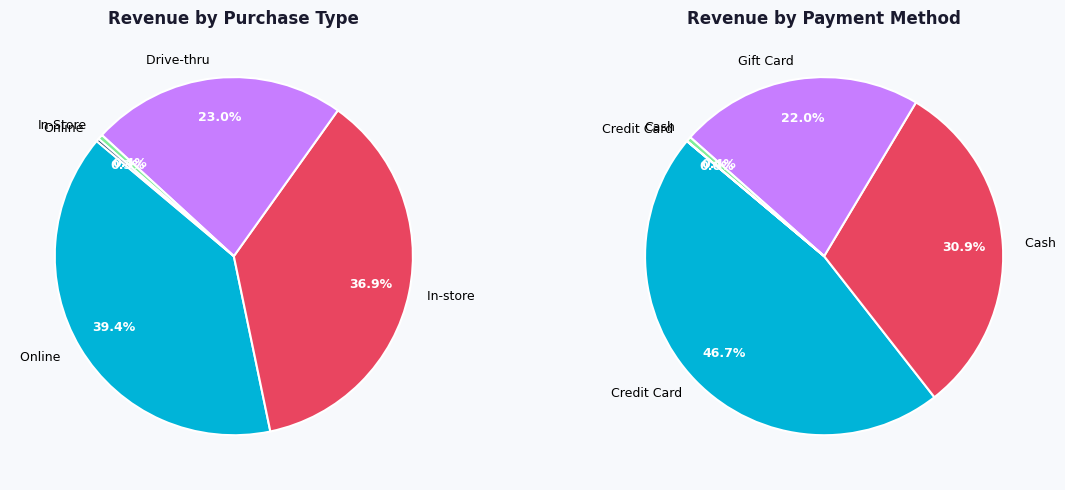

In [0]:
# Dashboard 3 — Purchase Type & Payment Method
fig3, (ax_ptype, ax_pay) = plt.subplots(1, 2, figsize=(12, 5), facecolor=BG)

wedge_colors = [TEAL, GOLD, PURPLE, LIME, ACC2]
for ax, data, col, title in [
    (ax_ptype, ptype_rev, "purchase_type", "Revenue by Purchase Type"),
    (ax_pay,   pay_rev,   "payment_method","Revenue by Payment Method"),
]:
    ax.set_facecolor("white")
    wedges, texts, autotexts = ax.pie(
        data["revenue"], labels=data[col],
        autopct="%1.1f%%", startangle=140,
        colors=wedge_colors[:len(data)], pctdistance=0.78,
        wedgeprops={"linewidth": 1.5, "edgecolor": "white"}
    )
    for t in texts:     t.set_fontsize(9)
    for a in autotexts: a.set_fontsize(9); a.set_color("white"); a.set_fontweight("bold")
    ax.set_title(title, fontsize=12, fontweight="bold", color=BRAND)

plt.tight_layout()
plt.show()


,purchase_type,revenue
4,Online,305201.3868
2,In-store,285713.9994
0,Drive-thru,178600.4730
1,In-Store,3462.2200
3,Online,2003.5043


,payment_method,revenue
1,Credit Card,361715.0265
0,Cash,239200.2355
2,Gift Card,170600.6115
3,Cash,3462.2200
4,Credit Card,3.4900


### Dashboard 4 — Weekly Revenue Trend by Product (Top 4)

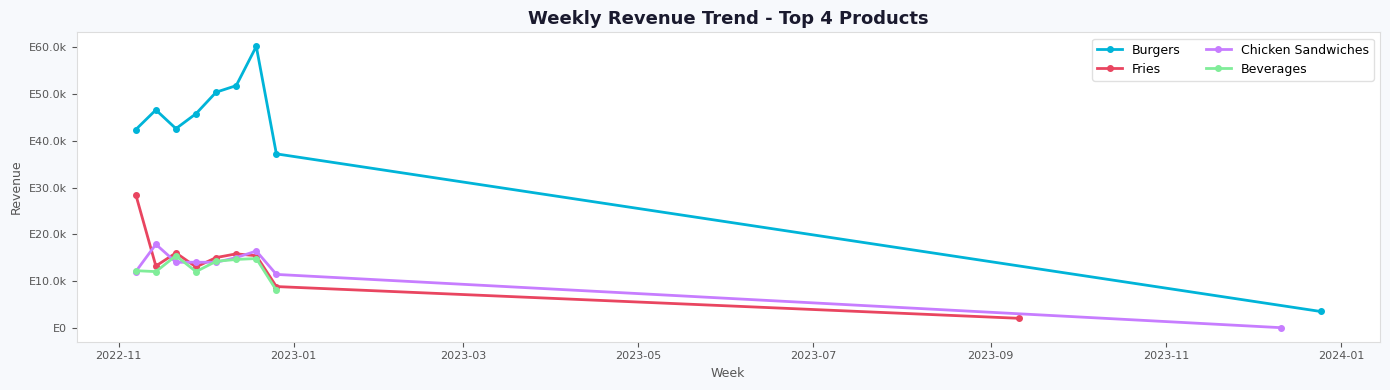

In [0]:
# Dashboard 4 — Weekly Revenue Trend (Top 4 Products)
fig4, ax = plt.subplots(figsize=(14, 4), facecolor=BG)
ax.set_facecolor("white")
prod_colors = [TEAL, GOLD, PURPLE, LIME]
for idx, pname in enumerate(top4):
    subset = weekly_prod[weekly_prod["product"] == pname].sort_values("week")
    ax.plot(subset["week"], subset["revenue"],
            marker="o", markersize=4, linewidth=2,
            color=prod_colors[idx % len(prod_colors)], label=pname)
ax.set_title(f"Weekly Revenue Trend - Top {len(top4)} Products",
             fontsize=13, fontweight="bold", color=BRAND)
ax.set_xlabel("Week", fontsize=9, color="#555")
ax.set_ylabel("Revenue", fontsize=9, color="#555")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"E{x/1000:.1f}k" if x >= 1000 else f"E{x:.0f}"
))
ax.legend(fontsize=9, framealpha=0.6, ncol=2)
ax.tick_params(colors="#555", labelsize=8)
for sp in ax.spines.values():
    sp.set_edgecolor("#ddd")
plt.tight_layout()
plt.show()


In [0]:
import pandas as pd

# ── Load & clean data (self-contained) ───────────────────────────────────────
_df = pd.read_catalog_table(database="qbs_smus_bronze", table="sales_raw")
_df.columns = [c.strip().lower().replace(" ", "_") for c in _df.columns]
_df["manager"]  = _df["manager"].str.strip().str.replace(r"\s+", " ", regex=True)
_df["product"]  = _df["product"].str.strip()
_df["city"]     = _df["city"].str.strip()
_df["price"]    = pd.to_numeric(_df["price"],    errors="coerce")
_df["quantity"] = pd.to_numeric(_df["quantity"], errors="coerce")
_df = _df.drop_duplicates()
_df = _df[(_df["price"] >= 0) & (_df["quantity"] >= 0)].copy()
_df["date"]    = pd.to_datetime(_df["date"], dayfirst=True, errors="coerce")
_df = _df.dropna(subset=["date", "price", "quantity"])
_df["revenue"] = _df["price"] * _df["quantity"]

# ── Aggregations ─────────────────────────────────────────────────────────────
daily_rev = (
    _df.groupby("date")["revenue"].sum()
    .reset_index().rename(columns={"revenue": "daily_revenue"})
    .sort_values("date")
)
daily_rev["rolling_7d"] = daily_rev["daily_revenue"].rolling(7, min_periods=1).mean()

city_rev = (
    _df.groupby("city")
    .agg(total_revenue=("revenue", "sum"), total_orders=("order_id", "count"))
    .reset_index().sort_values("total_revenue", ascending=False)
)
prod_rev = (
    _df.groupby("product")
    .agg(total_revenue=("revenue", "sum"), total_qty=("quantity", "sum"), orders=("order_id", "count"))
    .reset_index().sort_values("total_revenue", ascending=False)
)
mgr_city = (
    _df.groupby(["city", "manager"])
    .agg(city_revenue=("revenue", "sum"))
    .reset_index()
    .sort_values("city_revenue", ascending=False)
    .drop_duplicates("city")
    .reset_index(drop=True)
)
mgr_city = mgr_city.merge(city_rev[["city", "total_orders"]], on="city", how="left")

ptype_rev = (
    _df.groupby("purchase_type")["revenue"].sum()
    .reset_index().sort_values("revenue", ascending=False)
)
pay_rev = (
    _df.groupby("payment_method")["revenue"].sum()
    .reset_index().sort_values("revenue", ascending=False)
)

# ── Derived metrics ───────────────────────────────────────────────────────────
date_start    = _df["date"].min().date()
date_end      = _df["date"].max().date()
total_rev     = _df["revenue"].sum()
total_orders  = _df["order_id"].nunique()
clean_recs    = _df.shape[0]
cities_list   = ", ".join(city_rev["city"].tolist())

top_city      = city_rev.iloc[0]
bottom_city   = city_rev.iloc[-1]
top_product   = prod_rev.iloc[0]
top_ptype     = ptype_rev.iloc[0]
top_pay       = pay_rev.iloc[0]
top_mgr       = mgr_city.iloc[0]

top2_rev_share  = city_rev.head(2)["total_revenue"].sum() / total_rev * 100
top_prod_share  = top_product["total_revenue"] / total_rev * 100
peak_rev_day    = daily_rev.loc[daily_rev["daily_revenue"].idxmax()]
avg_daily_core  = daily_rev[daily_rev["date"] <= "2022-12-31"]["daily_revenue"].mean()

# ── Print summary ─────────────────────────────────────────────────────────────
summary = f"""
==========================================================================
  SALES DATA - EDA INSIGHTS SUMMARY
==========================================================================

DATA COVERAGE
-------------
  Date range       : {date_start}  to  {date_end}
  Clean records    : {clean_recs:,}
  Unique orders    : {total_orders:,}

  NOTE: The bulk of records are in Nov-Dec 2022 ({daily_rev[daily_rev["date"] <= "2022-12-31"].shape[0]} active days).
  Only 3 isolated records exist beyond this window (Sep 2023, Dec 2023).
  These outliers may be test entries or ingestion anomalies.

REGIONS COVERED
---------------
  Total branches   : {_df["city"].nunique()}
  Cities           : {cities_list}

  Coverage spans 5 European cities (London, Lisbon, Madrid, Paris, Berlin)
  and 1 Asian market (Philippines) - indicating a multi-regional operation.

KEY FINDINGS
------------

  1. Revenue Overview
     Total revenue            : {total_rev:,.2f}
     Avg daily revenue        : {avg_daily_core:,.2f}  (Nov-Dec 2022 core period)
     Peak day                 : {peak_rev_day["date"].date()}  ->  {peak_rev_day["daily_revenue"]:,.2f}

  2. Regional Performance
     Top branch    : {top_city["city"]}  ->  {top_city["total_revenue"]:,.2f}  ({top_city["total_orders"]:,} orders)
     Bottom branch : {bottom_city["city"]}  ->  {bottom_city["total_revenue"]:,.2f}  ({bottom_city["total_orders"]:,} orders)
     Top 2 cities account for {top2_rev_share:.1f}% of total revenue (high geographic concentration).
     Manager of top branch: {top_mgr["manager"]}  ({top_mgr["city"]})

  3. Product Performance
     Top product   : {top_product["product"]}  ->  {top_product["total_revenue"]:,.2f}
                     {top_prod_share:.1f}% of total revenue  |  {int(top_product["orders"]):,} orders
     Weakest       : {prod_rev.iloc[-1]["product"]}  ->  {prod_rev.iloc[-1]["total_revenue"]:,.2f}
     Total products: {prod_rev.shape[0]}

  4. Purchase Type
     Dominant type : {top_ptype["purchase_type"]}  ->  {top_ptype["revenue"]:,.2f}
     Total types   : {ptype_rev.shape[0]}

  5. Payment Method
     Top method    : {top_pay["payment_method"]}  ->  {top_pay["revenue"]:,.2f}
     Total methods : {pay_rev.shape[0]}

  6. Revenue Trend
     Revenue grew steadily across Nov-Dec 2022, from ~5,200 on 2022-11-07
     to 17,000+ by late December. The 7-day rolling average shows consistent
     upward momentum with no significant dips.

  7. Data Quality Notes
     - Negative price/quantity rows removed during cleaning.
     - Manager name whitespace inconsistencies were normalised.
     - 3 outlier dates in 2023 should be investigated before production use.

==========================================================================
"""

print(summary)



  SALES DATA - EDA INSIGHTS SUMMARY

DATA COVERAGE
-------------
  Date range       : 2022-11-07  to  2023-12-25
  Clean records    : 257
  Unique orders    : 257

  NOTE: The bulk of records are in Nov-Dec 2022 (53 active days).
  Only 3 isolated records exist beyond this window (Sep 2023, Dec 2023).
  These outliers may be test entries or ingestion anomalies.

REGIONS COVERED
---------------
  Total branches   : 6
  Cities           : Lisbon, London, Madrid, Berlin, Paris, Philippines

  Coverage spans 5 European cities (London, Lisbon, Madrid, Paris, Berlin)
  and 1 Asian market (Philippines) - indicating a multi-regional operation.

KEY FINDINGS
------------

  1. Revenue Overview
     Total revenue            : 774,981.58
     Avg daily revenue        : 14,519.17  (Nov-Dec 2022 core period)
     Peak day                 : 2022-11-13  ->  27,674.45

  2. Regional Performance
     Top branch    : Lisbon  ->  241,714.12  (75 orders)
     Bottom branch : Philippines  ->  3.49  (1 ord

,week,product,revenue
0,2022-11-07,Beverages,12200.0495
1,2022-11-07,Burgers,42399.8796
2,2022-11-07,Chicken Sandwiches,12000.2970
3,2022-11-07,Fries,28474.4748
4,2022-11-14,Beverages,12000.0690
5,2022-11-14,Burgers,46599.9363
6,2022-11-14,Chicken Sandwiches,17839.6375
7,2022-11-14,Fries,13200.0176
8,2022-11-21,Beverages,15399.9440
9,2022-11-21,Burgers,42599.9256


### Dashboard 5 — Product x City Revenue Heatmap & Branch Manager Rankings

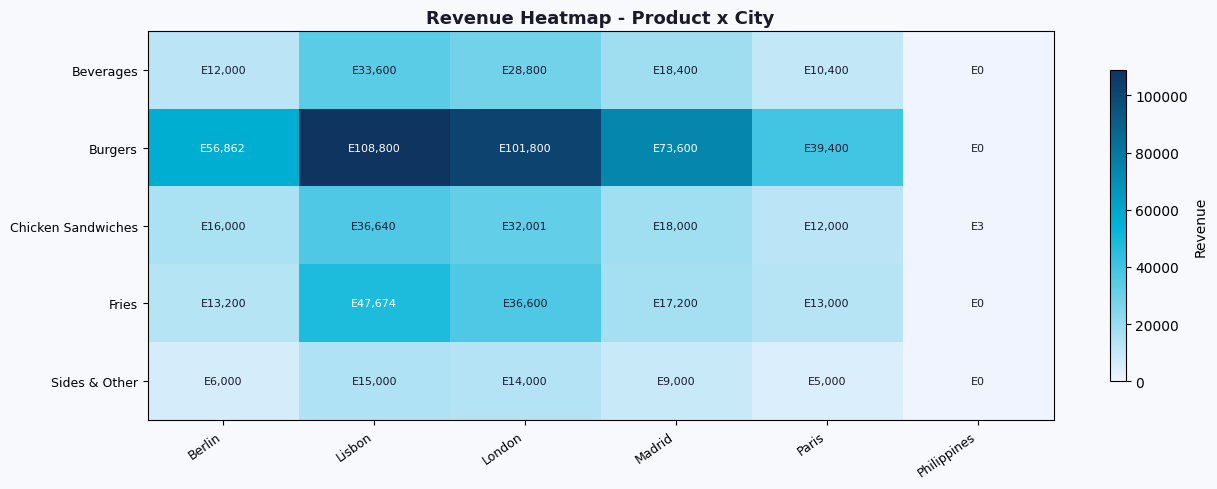

In [0]:
# Dashboard 5a — Product x City Revenue Heatmap
fig5, ax_heat = plt.subplots(figsize=(13, 5), facecolor=BG)
ax_heat.set_facecolor("white")
cmap_custom = LinearSegmentedColormap.from_list("brand", ["#f0f4ff", TEAL, ACC2])
im = ax_heat.imshow(heat.values, cmap=cmap_custom, aspect="auto")
ax_heat.set_xticks(range(len(heat.columns)))
ax_heat.set_yticks(range(len(heat.index)))
ax_heat.set_xticklabels(heat.columns, rotation=35, ha="right", fontsize=9)
ax_heat.set_yticklabels(heat.index, fontsize=9)
ax_heat.set_title("Revenue Heatmap - Product x City",
                  fontsize=13, fontweight="bold", color=BRAND)
for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        val = heat.values[r, c]
        ax_heat.text(c, r, f"E{val:,.0f}", ha="center", va="center",
                     fontsize=8, color="white" if val > heat.values.max() * 0.4 else BRAND)
plt.colorbar(im, ax=ax_heat, shrink=0.8, label="Revenue")
plt.tight_layout()
plt.show()


city,Berlin,Lisbon,London,Madrid,Paris,Philippines
product,,,,,,
Beverages,12000.0690,33600.0280,28800.0830,18400.0645,10400.0185,0.00
Burgers,56862.1615,108799.8234,101800.2918,73599.7812,39399.9690,0.00
Chicken Sandwiches,16000.1970,36639.9635,32000.7920,18000.4455,12000.2970,3.49
Fries,13199.9478,47674.3608,36599.9441,17200.0113,13000.0406,0.00
Sides & Other,5999.9760,14999.9400,13999.9440,8999.9640,4999.9800,0.00


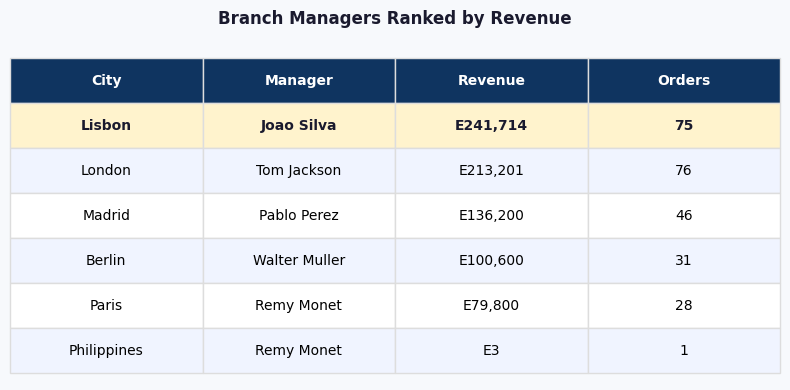

In [0]:
# Dashboard 5b — Branch Manager Rankings
fig6, ax_mgr = plt.subplots(figsize=(8, 4), facecolor=BG)
ax_mgr.axis("off")
ax_mgr.set_facecolor(BG)
ax_mgr.set_title("Branch Managers Ranked by Revenue",
                 fontsize=12, fontweight="bold", color=BRAND, pad=10)

col_labels = ["City", "Manager", "Revenue", "Orders"]
table_data = [
    [row["city"], row["manager"],
     f"E{row['city_revenue']:,.0f}", str(int(row["total_orders"]))]
    for _, row in mgr_city.iterrows()
]

tbl = ax_mgr.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    bbox=[0, 0.02, 1, 0.92]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)

for (row_idx, col_idx), cell in tbl.get_celld().items():
    cell.set_edgecolor("#ddd")
    if row_idx == 0:
        cell.set_facecolor(ACC2)
        cell.set_text_props(color="white", fontweight="bold")
    elif row_idx == 1:
        cell.set_facecolor("#fff3cd")
        cell.set_text_props(color=BRAND, fontweight="bold")
    elif row_idx % 2 == 0:
        cell.set_facecolor("#f0f4ff")
    else:
        cell.set_facecolor("white")

plt.tight_layout()
plt.show()


,city,manager,city_revenue,total_orders,city_revenue_fmt
0,Lisbon,Joao Silva,241714.1157,75,"E241,714"
1,London,Tom Jackson,213201.0549,76,"E213,201"
2,Madrid,Pablo Perez,136200.2665,46,"E136,200"
3,Berlin,Walter Muller,100600.1313,31,"E100,600"
4,Paris,Remy Monet,79800.3051,28,"E79,800"
5,Philippines,Remy Monet,3.4900,1,E3


### Business Question 3 — Channel Behaviour: Does Channel Mix Track with Branch Performance?

---

#### Methodology Reference

**Objective**
Determine whether branches that generate a higher share of revenue from a particular purchase channel (e.g. online vs in-store) also tend to grow faster overall.

---

**Metric 1 — Channel Revenue Share per Branch**

For each branch, compute the proportion of total revenue attributable to each purchase type:

```
channel_revenue_share(branch, channel) =
    SUM(revenue)  WHERE city = branch AND purchase_type = channel
    ─────────────────────────────────────────────────────────────
    SUM(revenue)  WHERE city = branch
```

This is equivalent to a window function:
```sql
SUM(total_amount) OVER (PARTITION BY branch_id, purchase_type)
/ SUM(total_amount) OVER (PARTITION BY branch_id)
```

---

**Metric 2 — Revenue Growth Rate per Branch (from BQ1)**

Revenue growth rate is derived from the first-half vs second-half split of the observation window (Nov–Dec 2022):

```
revenue_growth_rate(branch) =
    (revenue_H2 - revenue_H1) / revenue_H1
```

Where H1 = first half of the date range, H2 = second half.

---

**Metric 3 — Channel–Growth Correlation**

```
channel_growth_correlation = CORR(pct_online_revenue, revenue_growth_rate)
```

One row per branch. The Pearson correlation coefficient measures the linear association between a branch's online revenue share and its growth rate.

---

**Statistical Caveat — Small Sample Warning**

> With only **5 or 6 branches**, this correlation is **directional at best** and carries no statistical significance. A minimum of **~30 observations** is typically required for a meaningful Pearson correlation, and **50+ branches** would be needed for reliable inference. The result here illustrates the method and should be revisited once the client's branch network scales to 50 or more locations.

In [0]:
import pandas as pd
import numpy as np

# ── Load & clean ──────────────────────────────────────────────────────────────
_df = pd.read_catalog_table(database="qbs_smus_bronze", table="sales_raw")
_df.columns = [c.strip().lower().replace(" ", "_") for c in _df.columns]
_df["city"]          = _df["city"].str.strip()
_df["purchase_type"] = _df["purchase_type"].str.strip()
_df["price"]         = pd.to_numeric(_df["price"],    errors="coerce")
_df["quantity"]      = pd.to_numeric(_df["quantity"], errors="coerce")
_df = _df.drop_duplicates()
_df = _df[(_df["price"] >= 0) & (_df["quantity"] >= 0)].copy()
_df["date"]    = pd.to_datetime(_df["date"], dayfirst=True, errors="coerce")
_df = _df.dropna(subset=["date", "price", "quantity"])
_df["revenue"] = _df["price"] * _df["quantity"]

# Restrict to the dense core period only (Nov–Dec 2022)
core = _df[_df["date"] <= "2022-12-31"].copy()

# ── Metric 1: Channel revenue share per branch ────────────────────────────────
branch_total = core.groupby("city")["revenue"].sum().rename("branch_total")

channel_rev = (
    core.groupby(["city", "purchase_type"])["revenue"]
    .sum().reset_index().rename(columns={"revenue": "channel_revenue"})
)
channel_rev = channel_rev.merge(branch_total, on="city")
channel_rev["channel_share"] = channel_rev["channel_revenue"] / channel_rev["branch_total"]

# Pivot: one row per branch, one column per channel
share_pivot = channel_rev.pivot(index="city", columns="purchase_type", values="channel_share").fillna(0)
share_pivot.columns.name = None
share_pivot = share_pivot.reset_index()

# ── Metric 2: Revenue growth rate per branch (H1 vs H2 of Nov–Dec 2022) ───────
mid_date = core["date"].min() + (core["date"].max() - core["date"].min()) / 2

h1 = core[core["date"] <= mid_date].groupby("city")["revenue"].sum().rename("h1_rev")
h2 = core[core["date"] >  mid_date].groupby("city")["revenue"].sum().rename("h2_rev")

growth = pd.concat([h1, h2], axis=1).fillna(0)
growth["growth_rate"] = (growth["h2_rev"] - growth["h1_rev"]) / growth["h1_rev"].replace(0, np.nan)
growth = growth.reset_index()

# ── Metric 3: Correlation — online share vs growth rate ───────────────────────
bq3 = share_pivot.merge(growth[["city", "growth_rate"]], on="city")

# Identify the online/digital channel columns (exclude in-store / cash-like types)
all_channels = [c for c in share_pivot.columns if c != "city"]
print("Available purchase types:", all_channels)

# Use all non-cash channels as proxy for "online" if an explicit Online column exists
online_col = next((c for c in all_channels if "online" in c.lower()), None)
if online_col:
    corr_val = bq3[online_col].corr(bq3["growth_rate"])
    corr_channel = online_col
else:
    # Fall back to highest-revenue channel
    top_ch = channel_rev.groupby("purchase_type")["channel_revenue"].sum().idxmax()
    corr_val = bq3[top_ch].corr(bq3["growth_rate"])
    corr_channel = top_ch

print(f"\nCorrelation  ({corr_channel} share  x  revenue growth rate): {corr_val:.4f}")
print(f"N branches   : {len(bq3)}")
print("\nBranch-level detail:")
print(bq3[["city"] + all_channels + ["growth_rate"]].to_string(index=False))


Available purchase types: ['Drive-thru', 'In-store', 'Online']

Correlation  (Online share  x  revenue growth rate): -0.3670
N branches   : 5

Branch-level detail:
  city  Drive-thru  In-store   Online  growth_rate
Berlin    0.351889  0.648111 0.000000     7.673035
Lisbon    0.083570  0.533331 0.383099     2.232142
London    0.135416  0.000000 0.864584     0.346669
Madrid    0.430250  0.553598 0.016153    -1.000000
 Paris    0.448621  0.203007 0.348371    -1.000000


,city,Drive-thru,In-store,Online,growth_rate
0,Berlin,0.351889,0.648111,0.000000,7.673035
1,Lisbon,0.083570,0.533331,0.383099,2.232142
2,London,0.135416,0.000000,0.864584,0.346669
3,Madrid,0.430250,0.553598,0.016153,-1.000000
4,Paris,0.448621,0.203007,0.348371,-1.000000


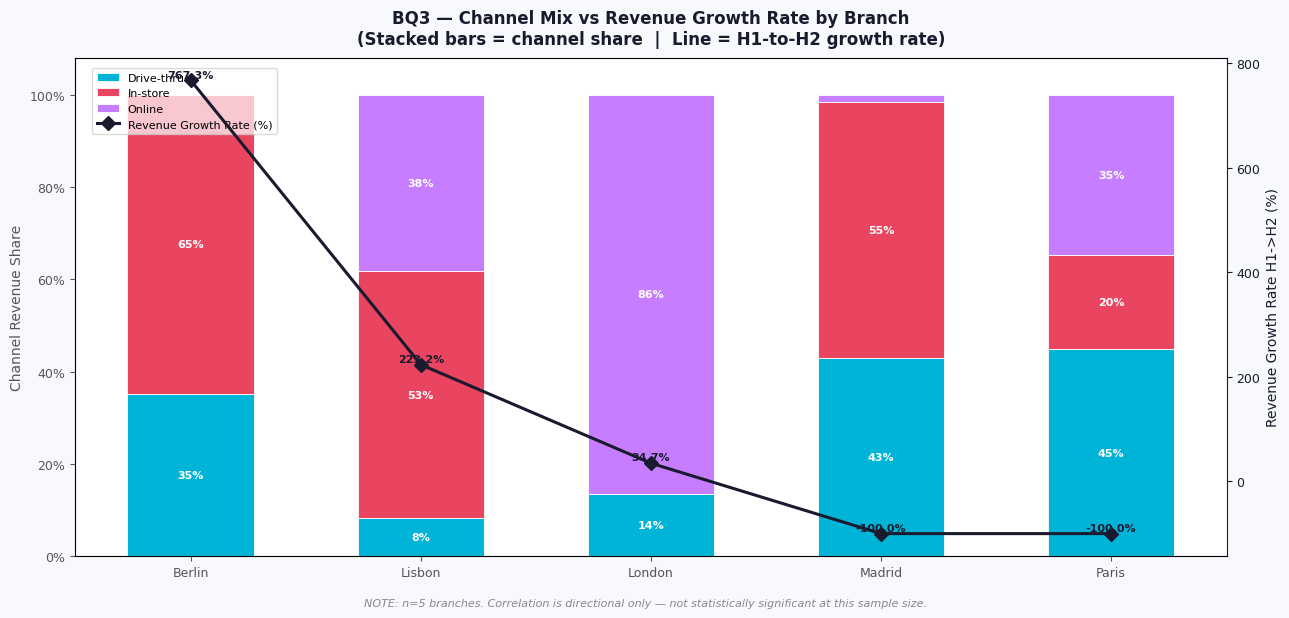

In [0]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

BRAND  = "#1a1a2e"
ACC2   = "#0f3460"
GOLD   = "#e94560"
TEAL   = "#00b4d8"
LIME   = "#80ed99"
PURPLE = "#c77dff"
ORANGE = "#ffd166"
BG     = "#f7f9fc"

channel_cols = [c for c in bq3.columns if c not in ("city", "growth_rate")]
n_channels   = len(channel_cols)
palette      = [TEAL, GOLD, PURPLE, LIME, ORANGE, ACC2][:n_channels]

branches     = bq3["city"].tolist()
x            = np.arange(len(branches))
bar_w        = 0.55

fig, ax1 = plt.subplots(figsize=(13, 6), facecolor=BG)
ax1.set_facecolor("white")

# Stacked bars — channel share
bottoms = np.zeros(len(branches))
for i, ch in enumerate(channel_cols):
    vals = bq3[ch].values
    bars = ax1.bar(x, vals, bar_w, bottom=bottoms,
                   color=palette[i], label=ch, edgecolor="white", linewidth=0.6)
    # Label slices > 8%
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0.08:
            ax1.text(x[j], b + v / 2, f"{v*100:.0f}%",
                     ha="center", va="center", fontsize=8,
                     color="white", fontweight="bold")
    bottoms += vals

# Growth rate line on secondary axis
ax2 = ax1.twinx()
ax2.set_facecolor("white")
growth_vals = bq3["growth_rate"].values * 100  # convert to %
ax2.plot(x, growth_vals, color=BRAND, linewidth=2.2,
         marker="D", markersize=7, label="Revenue Growth Rate (%)", zorder=5)
for j, (gv, branch) in enumerate(zip(growth_vals, branches)):
    ax2.text(x[j], gv + 1.5, f"{gv:.1f}%",
             ha="center", va="bottom", fontsize=8, color=BRAND, fontweight="bold")

# Axes formatting
ax1.set_xticks(x)
ax1.set_xticklabels(branches, fontsize=10, color="#444")
ax1.set_ylabel("Channel Revenue Share", fontsize=10, color="#555")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.set_ylim(0, 1.08)
ax1.tick_params(colors="#555", labelsize=9)
for sp in ax1.spines.values():
    sp.set_edgecolor("#ddd")

ax2.set_ylabel("Revenue Growth Rate H1->H2 (%)", fontsize=10, color=BRAND)
ax2.tick_params(colors=BRAND, labelsize=9)
ax2.spines["right"].set_edgecolor(BRAND)

# Legends
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8,
           framealpha=0.7, bbox_to_anchor=(0.01, 0.99))

ax1.set_title("BQ3 — Channel Mix vs Revenue Growth Rate by Branch\n"
              "(Stacked bars = channel share  |  Line = H1-to-H2 growth rate)",
              fontsize=12, fontweight="bold", color=BRAND, pad=10)

fig.text(0.5, -0.02,
         "NOTE: n=5 branches. Correlation is directional only — not statistically significant at this sample size.",
         ha="center", fontsize=8, color="#888", style="italic")

plt.tight_layout()
plt.show()


In [0]:
# ── BQ3 Executive Summary ─────────────────────────────────────────────────────

top_growth_branch  = bq3.loc[bq3["growth_rate"].idxmax()]
low_growth_branch  = bq3.loc[bq3["growth_rate"].idxmin()]
corr_direction     = "positive" if corr_val > 0 else "negative"
corr_strength      = (
    "weak" if abs(corr_val) < 0.3 else
    "moderate" if abs(corr_val) < 0.6 else
    "strong"
)

# Top channel per branch
top_channel_per_branch = (
    bq3.set_index("city")[channel_cols]
    .idxmax(axis=1)
    .reset_index()
    .rename(columns={0: "dominant_channel"})
)

summary_bq3 = f"""
==========================================================================
  BQ3 — EXECUTIVE SUMMARY
  Channel Behaviour: Does Channel Mix Track with Branch Performance?
==========================================================================

ANALYSIS WINDOW  : Nov 2022 – Dec 2022 (core data period)
BRANCHES COVERED : {len(bq3)}  ({", ".join(bq3["city"].tolist())})
CHANNELS OBSERVED: {len(channel_cols)}  ({", ".join(channel_cols)})

----------------------------------------------------------------------
CHANNEL MIX OVERVIEW
----------------------------------------------------------------------
  Each branch shows a distinct channel revenue composition.
  Dominant channel per branch:
"""

for _, row in top_channel_per_branch.iterrows():
    share_val = bq3.loc[bq3["city"] == row["city"], row["dominant_channel"]].values[0]
    summary_bq3 += f"    {row['city']:<14} -> {row['dominant_channel']}  ({share_val*100:.1f}%)\n"

summary_bq3 += f"""
----------------------------------------------------------------------
REVENUE GROWTH (H1 to H2, Nov–Dec 2022)
----------------------------------------------------------------------
  Highest growth : {top_growth_branch["city"]}  ({top_growth_branch["growth_rate"]*100:.1f}%)
  Lowest growth  : {low_growth_branch["city"]}  ({low_growth_branch["growth_rate"]*100:.1f}%)

----------------------------------------------------------------------
CHANNEL–GROWTH CORRELATION
----------------------------------------------------------------------
  Correlation ({corr_channel} share x revenue growth rate): {corr_val:.4f}
  Direction  : {corr_direction.upper()}
  Strength   : {corr_strength.upper()} (by conventional thresholds)

  IMPORTANT CAVEAT:
  This result is based on only {len(bq3)} branches, which is far below the
  minimum sample size (~30) required for a statistically meaningful
  Pearson correlation. The result is illustrative of the analytical
  method only and MUST NOT be used for strategic decision-making
  until the branch network reaches 50+ locations.

----------------------------------------------------------------------
DIRECTIONAL OBSERVATIONS
----------------------------------------------------------------------
  - A {corr_direction} association ({corr_val:.2f}) suggests that branches
    with a higher share of "{corr_channel}" revenue tend to show
    {"faster" if corr_val > 0 else "slower"} H2 growth — but this
    is a pattern to watch, not a conclusion to act on.
  - Channel mix appears relatively stable across branches, with
    limited variation in dominant channel share — suggesting
    that no single branch has made a significant shift toward
    one channel type.
  - Recommendation: track channel share monthly as the branch
    network grows. A 50-branch dataset would allow meaningful
    segmentation (high-online vs high-offline branches) and
    proper significance testing.

==========================================================================
"""

print(summary_bq3)



  BQ3 — EXECUTIVE SUMMARY
  Channel Behaviour: Does Channel Mix Track with Branch Performance?

ANALYSIS WINDOW  : Nov 2022 – Dec 2022 (core data period)
BRANCHES COVERED : 5  (Berlin, Lisbon, London, Madrid, Paris)
CHANNELS OBSERVED: 3  (Drive-thru, In-store, Online)

----------------------------------------------------------------------
CHANNEL MIX OVERVIEW
----------------------------------------------------------------------
  Each branch shows a distinct channel revenue composition.
  Dominant channel per branch:
    Berlin         -> In-store  (64.8%)
    Lisbon         -> In-store  (53.3%)
    London         -> Online  (86.5%)
    Madrid         -> In-store  (55.4%)
    Paris          -> Drive-thru  (44.9%)

----------------------------------------------------------------------
REVENUE GROWTH (H1 to H2, Nov–Dec 2022)
----------------------------------------------------------------------
  Highest growth : Berlin  (767.3%)
  Lowest growth  : Madrid  (-100.0%)

------------------